In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"]="jshtml"

List_methode_de_flux= ["primitive","conservative"]
List_condition_limite=["Neumann","Dirichlet","Periodique"]

In [105]:
class Finite_Volume:


    def __init__(self,K_l,K_r, flux_methode, film_bool =False, condition_limite = "Neumann",  ghost_nodes=[0,0], domaine=(0.,1.) ):
        Valid_init = True
        self.flux = lambda u,v,xi,xj :0*u+0*v
        self.k = lambda x: K_l*(x<0) + K_r*(x>=0)

        in_list =False
        for methode in List_methode_de_flux:
            if(flux_methode ==methode):  in_list =True
        if(not in_list): Valid_init = False

        in_list =False
        for condition in List_condition_limite:
            if(condition_limite ==condition): in_list =True
        if(not in_list): Valid_init = False
        
    
        self.flux_methode = flux_methode;   self.condition_limite = condition_limite
        self.ghost_nodes=ghost_nodes
        self.film_bool = film_bool
        self.domaine= domaine
        if(not Valid_init): f"Methode non reconnue"

    def flux_function(self):
        k = lambda x: self.k(x)

        if(self.flux_methode == "primitive"):
            self.flux= lambda u,v,xi,xj : 2*k(xi)*k(xj)/(k(xi)+k(xj)) * u*(1-v)/(u+(1-v))
        elif(self.flux_methode =="conservative"):
            self.flux= lambda u,v,xi,xj : (k(xi)*u * k(xj)*(1-v) )/(k(xi)*u + k(xj)*(1-v)) 


    def sol(self, u0, J,T,  CFL=0.5, nb_images=30):
        dx = 1./J
        
        a= self.domaine[0]; b= self.domaine[1]

        X = np.linspace(a+dx,b,J) -dx/2


        f = lambda u,x: self.k(x)*u*(1-u) ; 
        flux = self.flux
        U = u0(X)

        FG = np.empty_like(X) 
        FD = np.empty_like(X)

        
        U_sol = []; dt_list=[]
        vitesse=0

        t=0.; n =0; dt=0.
        while t<T and n<10000:
            #calcul de dt

            vitesse = max(vitesse, max(self.k(X)*(1-2*U)))

            if(vitesse !=0) : dt = (min(CFL * dx /(2* vitesse), T-t))
            else :            dt = CFL*dx  

            if(dt<0): dt = 10e-10; print(f"!!!!!!!!!!!!!!!!! dt<0 !!!!!!!!!")

            ## Calcul du flux
            for j in range(len(X)):
                
                if(j==0):   
                    if(self.condition_limite =="Dirichlet"):    FG[j] = flux(self.ghost_nodes[0],U[j],a,a+dx )
                    elif(self.condition_limite =="Neumann"):    FG[j] = flux(U[j]+self.ghost_nodes[0],U[j],a,a+dx)
                    elif(self.condition_limite =="Periodique"): FG[j] = flux(U[-1], U[j],b,a)

                else :      FG[j]= flux(U[j-1],U[j],(j-1)*dx,j*dx); 
                
                if(j==J-1):   
                    if(self.condition_limite =="Dirichlet"):    FD[j] = flux(U[j], self.ghost_nodes[1],b,b+dx)
                    elif(self.condition_limite =="Neumann"):    FD[j] = flux(U[j], U[j]+self.ghost_nodes[1],b,b+dx)
                    elif(self.condition_limite =="Periodique"): FD[j] = flux(U[j], U[0],b,a)

                else :      FD[j]= flux(U[j],U[j+1],j*dx,(j+1)*dx) 

            # print(max(FD), max)

            ## eval
            U_sol.append(U.copy())

            ## Calcul de la solution
            for j in range(len(X)):
                U[j] = U[j] -(dt/dx)* (FD[j]-FG[j])

            n+=1; t+= dt; dt_list.append(dt)
            if n%10 :print("------ ---- t= ",t," -----------------")

        U_anime = []; nb_iter = min(len(U_sol)-1, nb_images)
        for i in np.linspace(0,len(U_sol)-1,nb_iter): U_anime.append(U_sol[int(i)])
        self.anime = U_anime; self.dt_list = dt_list

    def show_sol(self,bound=[0,0]):

        lenght_animation = len(self.anime); T= sum(self.dt_list); L=self.domaine[1]-self.domaine[0]
        print(lenght_animation)

        J = len(self.anime[0]); 
        dx = (self.domaine[1]- self.domaine[0])/J

        X= np.linspace(self.domaine[0],self.domaine[1],J,endpoint=False) -dx/2

        fig, (ax , ax_film) = plt.subplots(1,2)
        
        imag_xt =  np.zeros((lenght_animation,J))
        for i in range(lenght_animation) : imag_xt[i,:] = self.anime[lenght_animation -i-1]
        im = ax_film.imshow(imag_xt,extent=((self.domaine[0], self.domaine[1], 0,T)))
        

        fig.colorbar(im, ax=ax_film, label='Interactive colorbar')
        ax_film.set_aspect(L/T)
        ax_film.set_ylabel("t")
        ax_film.set_xlabel("x")

        line = ax_film.plot(X, 0*X,'r')[0]

        m = min(np.min(self.anime)*0.9,bound[0]); M = max(np.max(self.anime)*1.1,bound[1])

        ax.set(xlim=[self.domaine[0],self.domaine[1]], ylim=[m,M], xlabel='x', ylabel='U')

        u_plot = ax.plot(X, self.anime[0],'b', label="u")[0]

        ax.legend(fancybox=True, shadow=True, loc='upper left')     


        def update(i):
            t= sum(self.dt_list[:i])
            print(i+1,"/",lenght_animation)
            # IPython.display.clear_output(wait=True)
            u_plot.set_ydata(self.anime[i])
            line.set_ydata(i*T/(lenght_animation) +0*X)
            

        anime = animation.FuncAnimation(fig=fig, func=update, frames=lenght_animation)
        return anime
    

In [106]:
#
ul=0.5;ur=0.3
U0  = lambda x: ul*(x<0.) + ur*(x>=0.)

Fv = Finite_Volume(K_l=2,K_r=1 ,flux_methode="conservative",film_bool=True, condition_limite="Neumann", domaine=[-5,5])

Fv.flux_function()
Fv.sol(U0,J=100,T=4,CFL=0.9)
anime =Fv.show_sol(bound=[0,1])
plt.close()
anime

------ ---- t=  0.011250000000000001  -----------------
------ ---- t=  0.022500000000000003  -----------------
------ ---- t=  0.03375  -----------------
------ ---- t=  0.045000000000000005  -----------------
------ ---- t=  0.05625000000000001  -----------------
------ ---- t=  0.0675  -----------------
------ ---- t=  0.07875  -----------------
------ ---- t=  0.09  -----------------
------ ---- t=  0.10124999999999999  -----------------
------ ---- t=  0.12374999999999999  -----------------
------ ---- t=  0.13499999999999998  -----------------
------ ---- t=  0.14625  -----------------
------ ---- t=  0.1575  -----------------
------ ---- t=  0.16875  -----------------
------ ---- t=  0.18000000000000002  -----------------
------ ---- t=  0.19125000000000003  -----------------
------ ---- t=  0.20250000000000004  -----------------
------ ---- t=  0.21375000000000005  -----------------
------ ---- t=  0.23625000000000007  -----------------
------ ---- t=  0.24750000000000008  ----

0.8 0.95
------ ---- t=  0.045000000000000005  -----------------
0.42027173913043514 1.3775000000000004
------ ---- t=  0.09000000000000001  -----------------
-3.3025562500000056 1.4809957022658977
------ ---- t=  0.135  -----------------
-131.18746255972695 3.184727642080526
------ ---- t=  0.18000000000000002  -----------------
-156203.22762133513 5.526256936820947
------ ---- t=  0.22500000000000003  -----------------
-219596596906.17993 18.944438688154264
------ ---- t=  0.27  -----------------
-4.340039883571734e+23 43.884230376366574
------ ---- t=  0.315  -----------------
-inf 145.19511941917733
------ ---- t=  0.36  -----------------
nan nan
------ ---- t=  0.40499999999999997  -----------------
nan nan
nan nan
------ ---- t=  0.49499999999999994  -----------------
nan nan
------ ---- t=  0.5399999999999999  -----------------
nan nan
------ ---- t=  0.585  -----------------
nan nan
------ ---- t=  0.63  -----------------
nan nan
------ ---- t=  0.675  -----------------
nan nan

C:\Users\cleme\AppData\Local\Temp\ipykernel_29472\1022164555.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  self.flux= lambda u,v,xi,xj : (k(xi)*u * k(xj)*(1-v) )/(k(xi)*u + k(xj)*(1-v))
C:\Users\cleme\AppData\Local\Temp\ipykernel_29472\1022164555.py:40: RuntimeWarning: invalid value encountered in scalar add
  self.flux= lambda u,v,xi,xj : (k(xi)*u * k(xj)*(1-v) )/(k(xi)*u + k(xj)*(1-v))
C:\Users\cleme\AppData\Local\Temp\ipykernel_29472\1022164555.py:40: RuntimeWarning: invalid value encountered in scalar multiply
  self.flux= lambda u,v,xi,xj : (k(xi)*u * k(xj)*(1-v) )/(k(xi)*u + k(xj)*(1-v))


ValueError: Axis limits cannot be NaN or Inf

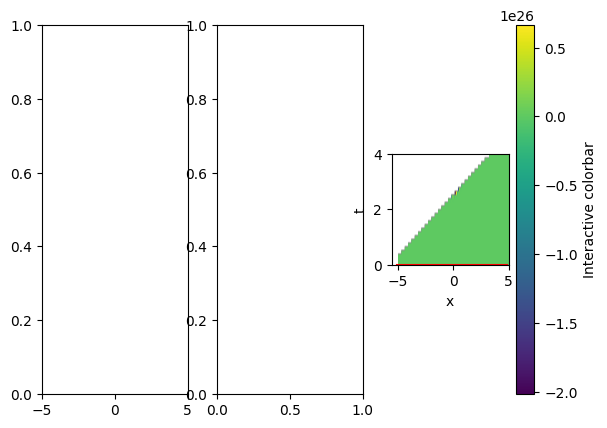

In [ ]:
#
ul=0.95;ur=0.8
U0  = lambda x: ul*(x<0.) + ur*(x>=0.)

Fv = Finite_Volume(K_l=2,K_r=1 ,flux_methode="conservative",film_bool=True, condition_limite="Neumann", domaine=[-5,5])

J=100
Fv.flux_function(dx=1/J)
Fv.sol(U0,J=J,T=4,CFL=0.9)
anime =Fv.show_sol(bound=[0,1])
plt.close()
anime